# District data cleaning (fixed)

Changes from the original notebook:

- `" Matu Daro"` key had a leading space, so the crime rows for Matu Daro were never merged into `Matu/Daro`. The key is corrected.
- `Serdang` (a police district under Petaling, see the original note) had no entry in any map. It is now merged into `Petaling`.
- District names are resolved through the maps until they stop changing, so one pass gives the final name (the original relied on running the loop several times).
- `Padawan` (and `Siburan`, which was mapped to it) is merged into `Kuching`. Padawan enrolment starts in 2023, when Kuching's enrolment drops by about the same amount, so summing restores a continuous series.
- Count columns (population, schools, students, crimes) are still summed.
- Rate and level columns (income, poverty, gini, amenities) are combined with a population-weighted mean instead of a sum.
- Missing amenities values stay missing instead of becoming 0.

In [1]:
import pandas as pd
import numpy as np

In [2]:
crime = pd.read_csv('data/crime_district.csv')
amenities = pd.read_csv('data/hh_access_amenities.csv')
income = pd.read_csv('data/hh_income_district.csv')
inequality = pd.read_csv('data/hh_inequality_district.csv')
poverty = pd.read_csv('data/hh_poverty_district.csv')
pop_dist = pd.read_csv('data/population_district.csv')
schools_dist = pd.read_csv('data/schools_district.csv')
enrolment = pd.read_csv('data/enrolment_school_district.csv')

dfs = {
    'income': income, 'poverty': poverty, 'inequality': inequality,
    'amenities': amenities, 'population': pop_dist, 'crime': crime,
    'schools': schools_dist, 'enrolment': enrolment,
}

In [3]:
# Drop aggregate summary rows from all raw datasets
for name in dfs:
    dfs[name] = dfs[name][~dfs[name]['district'].isin(['All', 'All Districts'])]

## Name maps

The districts are not consistent across datasets. Crime data uses IPD (police) districts, education data uses PPD districts, and the rest use administrative districts. Names are respelled, and sub-units are merged into the district that carries the data in the other datasets. The IPD merges below are the ones recorded in the original notebook (as of 29 Sep 2026).

In [4]:
wp_renames = {
    "W.P. Kuala Lumpur": "Kuala Lumpur",
    "W.P. Labuan": "Labuan",
    "W.P. Putrajaya": "Putrajaya"
}

# spelling / naming differences only
safe_renames = {
    "Kulaijaya": "Kulai", "Ledang": "Tangkak", "Bandar Bharu": "Bandar Baharu",
    "Pasir Putih": "Pasir Puteh", "Cameron Highland": "Cameron Highlands",
    "Kuala Lipis": "Lipis", "Larut & Matang": "Larut dan Matang",
    "Larut Dan Matang": "Larut dan Matang", "Larut Matang & Selama": "Larut/Matang/Selama",
    "Manjung (Dinding)": "Manjung", "Jpn Perlis": "Perlis",
    "S.P. Selatan": "Seberang Perai Selatan", "Sp Selatan": "Seberang Perai Selatan",
    "S.P.Tengah": "Seberang Perai Tengah", "Sp Tengah": "Seberang Perai Tengah",
    "S.P.Utara": "Seberang Perai Utara", "Sp Utara": "Seberang Perai Utara",
    "Kota Kinabatangan": "Kinabatangan", "Pensiangan": "Nabawan",
    "Kota Samarahan": "Samarahan", "Lubok antu": "Lubok Antu", "Meradong": "Maradong",
    "Hulu Langat": "Ulu Langat", "Hulu Selangor": "Ulu Selangor", "Sg. Buloh": "Sungai Buloh",
    "Hulu": "Hulu Terengganu"
}

sub_districts_to_parents = {
    "Johor Bahru Selatan": "Johor Bahru", "Johor Bahru Utara": "Johor Bahru",
    "Iskandar Puteri": "Johor Bahru", "Nusajaya": "Johor Bahru",
    "Seri Alam": "Johor Bahru", "Pasir Gudang": "Johor Bahru",
    "Nilai": "Seremban", "Ipoh": "Kinta", "Batu Gajah": "Kinta",
    "Kinta Selatan": "Kinta", "Kinta Utara": "Kinta", "Sungai Siput": "Kuala Kangsar",
    "Gerik": "Hulu Perak", "Pengkalan Hulu": "Hulu Perak", "Tapah": "Batang Padang",
    "Tanjong Malim": "Muallim", "Taiping": "Larut dan Matang",
    "Arau": "Perlis", "Kangar": "Perlis", "Padang Besar": "Perlis",
    "Ampang Jaya": "Ulu Langat", "Kajang": "Ulu Langat", "Klang Selatan": "Klang",
    "Klang Utara": "Klang", "Petaling Jaya": "Petaling", "Subang Jaya": "Petaling",
    "Shah Alam": "Petaling", "Sungai Buloh": "Petaling", "Petaling Perdana": "Petaling",
    "Petaling Utama": "Petaling", "Brickfields": "Kuala Lumpur",
    "Cheras": "Kuala Lumpur", "Dang Wangi": "Kuala Lumpur",
    "Sentul": "Kuala Lumpur", "Wangsa Maju": "Kuala Lumpur",
    # Serdang is its own police district but is under Petaling administratively
    "Serdang": "Petaling"
}

fine_to_combined = {
    "Kuala Muda": "Kuala Muda/Yan", "Yan": "Kuala Muda/Yan",
    "Kulim": "Kulim/Bandar Baharu", "Bandar Baharu": "Kulim/Bandar Baharu",
    "Jempol": "Jempol/Jelebu", "Jelebu": "Jempol/Jelebu",
    "Larut dan Matang": "Larut/Matang/Selama", "Selama": "Larut/Matang/Selama",
    "Telupid": "Telupid/Tongod", "Tongod": "Telupid/Tongod",
    "Tatau": "Tatau/Sebauh", "Sebauh": "Tatau/Sebauh",
    "Matu": "Matu/Daro", "Daro": "Matu/Daro", "Matu Daro": "Matu/Daro"
}

# districts with no crime data, merged into their IPD
ipd_merges = {
    "Pokok Sena": "Kota Setar",
    "Kecil Lojing": "Gua Musang",
    "Bagan Datuk": "Hilir Perak",
    "Kuala Nerus": "Kuala Terengganu",
    "Kalabakan": "Tawau",
    "Kuala Penyu": "Beaufort", "Membakut": "Beaufort",
    "Nabawan": "Keningau", "Tambunan": "Keningau",
    "Pitas": "Kota Marudu",
    "Putatan": "Penampang",
    "Telupid/Tongod": "Beluran",
    "Asajaya": "Samarahan",
    "Beluru": "Marudi", "Telang Usan": "Marudi", "Baram": "Marudi",
    "Bukit Mabong": "Kapit",
    "Gedong": "Simunjan",
    "Kabong": "Saratok", "Pusa": "Saratok",
    "Lingga": "Sri Aman", "Pantu": "Sri Aman", "Sebuyau": "Sri Aman",
    "Pakan": "Julau",
    "Selangau": "Mukah",
    "Siburan": "Padawan",
    "Padawan": "Kuching",
    "Subis": "Miri",
    "Tanjung Manis": "Sarikei",
    "Tebedu": "Serian",
}

master_map = {**safe_renames, **sub_districts_to_parents,
              **fine_to_combined, **ipd_merges, **wp_renames}

`resolve` follows the maps until the name stops changing, so a chain such as `Telupid` -> `Telupid/Tongod` -> `Beluran` is handled in one pass. `spelling` applies only the respelling maps and gives the unit name used to look up population weights.

In [5]:
def resolve(name):
    seen = set()
    while name in master_map and name not in seen:
        seen.add(name)
        name = master_map[name]
    return name

spelling_map = {**safe_renames, **wp_renames}

def spelling(name):
    return spelling_map.get(name, name)

def standardise_labels(df):
    d = df.copy()
    d['state'] = d['state'].str.strip()
    d['district'] = d['district'].str.strip()
    # Putrajaya and Labuan are their own states (crime data nests Putrajaya under Kuala Lumpur)
    d.loc[d['district'].isin(['W.P. Putrajaya', 'Putrajaya']), 'state'] = 'Putrajaya'
    d.loc[d['district'].isin(['W.P. Labuan', 'Labuan']), 'state'] = 'Labuan'
    d['state'] = d['state'].replace(wp_renames)
    d['unit'] = d['district'].map(spelling)
    d['district'] = d['district'].map(resolve)
    return d

## Count datasets

Population, schools, students and crimes are counts, so merged districts are summed.

In [6]:
count_keys = ['state', 'district', 'date', 'category', 'type', 'stage', 'sex', 'age', 'ethnicity']

def combine_counts(df):
    d = standardise_labels(df).drop(columns='unit')
    keys = [c for c in count_keys if c in d.columns]
    return d.groupby(keys).sum().reset_index()

clean = {name: combine_counts(dfs[name]) for name in ['population', 'schools', 'enrolment', 'crime']}

## Rate and level datasets

Income, poverty, gini and the amenities percentages cannot be summed. Rows that merge into one district are combined with a mean weighted by the population of each unit (both sexes, all ages, all ethnicities).

- Population is available for 2020-2025. Rows dated before 2020 use the 2020 population.
- If any contributing unit has no population row (Membakut, Gedong, Sebuyau, Pantu, Lingga, Siburan), the group uses a simple mean. These groups are listed below.
- Missing values are skipped. A group with no values stays missing.
- Weighted means of medians and of gini are approximations, since the underlying household data is not available.

In [7]:
w = standardise_labels(dfs['population'])
w = w[(w['sex'] == 'both') & (w['age'] == 'overall') & (w['ethnicity'] == 'overall')]
w['wyear'] = w['date'].str[:4].astype(int)
weights = w.groupby(['state', 'unit', 'wyear'])['population'].sum().rename('w').reset_index()

In [8]:
fallback_groups = []

def combine_rates(name, cols):
    d = standardise_labels(dfs[name])
    d['wyear'] = d['date'].str[:4].astype(int).clip(2020, 2025)
    d = d.merge(weights, on=['state', 'unit', 'wyear'], how='left')
    rows = []
    for (state, district, date), g in d.groupby(['state', 'district', 'date']):
        row = {'state': state, 'district': district, 'date': date}
        for c in cols:
            v = g[c].dropna()
            wt = g.loc[v.index, 'w']
            if len(v) == 0:
                row[c] = np.nan
            elif len(v) == 1:
                row[c] = v.iloc[0]
            elif wt.isna().any() or (wt <= 0).any():
                row[c] = v.mean()
                fallback_groups.append((name, state, district, date, sorted(g['unit'])))
            else:
                row[c] = np.average(v, weights=wt)
        rows.append(row)
    return pd.DataFrame(rows), d

rate_cols = {
    'income': ['income_mean', 'income_median'],
    'poverty': ['poverty_absolute', 'poverty_relative'],
    'inequality': ['gini'],
    'amenities': ['piped_water', 'sanitation', 'electricity'],
}

pre_merge = {}
for name, cols in rate_cols.items():
    clean[name], pre_merge[name] = combine_rates(name, cols)

In [9]:
pd.DataFrame(fallback_groups, columns=['dataset', 'state', 'district', 'date', 'units']).drop_duplicates(subset=['dataset', 'state', 'district', 'date'])

,dataset,state,district,date,units
0,income,Sabah,Beaufort,2024-01-01,"[Beaufort, Kuala Penyu, Membakut]"
2,income,Sarawak,Kuching,2024-01-01,"[Kuching, Siburan]"
4,income,Sarawak,Simunjan,2024-01-01,"[Gedong, Simunjan]"
6,income,Sarawak,Sri Aman,2024-01-01,"[Lingga, Pantu, Sebuyau, Sri Aman]"
8,poverty,Sabah,Beaufort,2024-01-01,"[Beaufort, Kuala Penyu, Membakut]"
10,poverty,Sarawak,Kuching,2024-01-01,"[Kuching, Siburan]"
12,poverty,Sarawak,Simunjan,2024-01-01,"[Gedong, Simunjan]"
14,poverty,Sarawak,Sri Aman,2024-01-01,"[Lingga, Pantu, Sebuyau, Sri Aman]"
16,inequality,Sabah,Beaufort,2024-01-01,"[Beaufort, Kuala Penyu, Membakut]"
17,inequality,Sarawak,Kuching,2024-01-01,"[Kuching, Siburan]"


## Checks

In [10]:
# row counts before and after
pd.DataFrame({'raw': {k: len(v) for k, v in dfs.items()}, 'clean': {k: len(v) for k, v in clean.items()}})

,raw,clean
income,480,389
poverty,480,389
inequality,480,389
amenities,640,524
population,383040,313614
crime,17472,14672
schools,3569,3138
enrolment,11433,10149


In [11]:
# merged names that were broken in the original
for name in ['crime']:
    d = clean[name]
    assert 'Matu Daro' not in set(d['district'])
    assert 'Serdang' not in set(d['district'])
print(clean['crime'].query("district == 'Matu/Daro'")['date'].str[:4].unique())
print(clean['crime'].query("district == 'Petaling'")['crimes'].sum() > dfs['crime'].query("district == 'Petaling'")['crimes'].sum())

['2016' '2017' '2018' '2019' '2020' '2021' '2022' '2023']
True


In [12]:
# each merged rate must lie between the smallest and largest value of its members
for name, cols in rate_cols.items():
    d = pre_merge[name]
    lim = d.groupby(['state', 'district', 'date'])[cols].agg(['min', 'max'])
    out = clean[name].set_index(['state', 'district', 'date'])
    for c in cols:
        ok = out[c].isna() | ((out[c] >= lim[(c, 'min')] - 1e-9) & (out[c] <= lim[(c, 'max')] + 1e-9))
        assert ok.all(), (name, c)
print('rates within member range')

rates within member range


In [13]:
a = clean['amenities']
print(a[['piped_water', 'sanitation', 'electricity']].max())
print(a[['piped_water', 'sanitation', 'electricity']].isna().sum())
print((a[['piped_water', 'sanitation', 'electricity']] == 0).sum())
assert (a[['piped_water', 'sanitation', 'electricity']].max() <= 100 + 1e-9).all()

piped_water    100.0
sanitation     100.0
electricity    100.0
dtype: float64
piped_water    1
sanitation     1
electricity    1
dtype: int64
piped_water    0
sanitation     0
electricity    0
dtype: int64


In [14]:
# districts of the merged rate example
clean['income'].query("district == 'Marudi'").merge(clean['inequality'].query("district == 'Marudi'"), on=['state', 'district', 'date'])

,state,district,date,income_mean,income_median,gini
0,Sarawak,Marudi,2019-01-01,4339.141757,3257.186441,0.361582
1,Sarawak,Marudi,2022-01-01,4970.361371,4104.816199,0.321717
2,Sarawak,Marudi,2024-01-01,5038.156550,4378.782748,0.256367


In [15]:
cols = []
for name, d in clean.items():
    g = d.assign(year=d['date'].str[:4]).groupby(['state', 'district'])['year'].agg(['min', 'max'])
    cols.append((g['min'] + '-' + g['max']).rename(name))

yrs_w_data = pd.concat(cols, axis=1).fillna('')
yrs_w_data.loc['Sarawak']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Bau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Belaga,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Betong,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Bintulu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Dalat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Julau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kanowit,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kapit,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuching,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [16]:
yrs_w_data.loc['Selangor']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Gombak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Klang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Langat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Selangor,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Petaling,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Sabak Bernam,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Sepang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Ulu Langat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Ulu Selangor,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [17]:
yrs_w_data.loc['Johor']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Batu Pahat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Johor Bahru,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kluang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Tinggi,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kulai,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Mersing,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Muar,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pontian,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Segamat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [18]:
yrs_w_data.loc['Kedah']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Baling,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Setar,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Muda/Yan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kubang Pasu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kulim/Bandar Baharu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Langkawi,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Padang Terap,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pendang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Sik,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [19]:
yrs_w_data.loc['Kelantan']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Bachok,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Gua Musang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Jeli,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Bharu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Krai,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Machang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pasir Mas,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pasir Puteh,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Tanah Merah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [20]:
yrs_w_data.loc['Kuala Lumpur']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Kuala Lumpur,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [21]:
yrs_w_data.loc['Labuan']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Labuan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [22]:
yrs_w_data.loc['Melaka']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Alor Gajah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Jasin,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Melaka Tengah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [23]:
yrs_w_data.loc['Negeri Sembilan']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Jempol/Jelebu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Pilah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Port Dickson,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Rembau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seremban,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Tampin,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [24]:
yrs_w_data.loc['Pulau Pinang']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Barat Daya,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seberang Perai Selatan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seberang Perai Tengah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seberang Perai Utara,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Timur Laut,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [25]:
yrs_w_data.loc['Perlis']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Perlis,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [26]:
yrs_w_data.loc['Perak']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Batang Padang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Hilir Perak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Hulu Perak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kampar,2020-2025,2017-2025,2018-2022,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kerian,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kinta,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Kangsar,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Larut/Matang/Selama,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Manjung,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [27]:
yrs_w_data.loc['Pahang']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Bentong,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Bera,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Cameron Highlands,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Jerantut,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuantan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Lipis,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Maran,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pekan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Raub,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [28]:
yrs_w_data.loc['Putrajaya']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Putrajaya,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [29]:
yrs_w_data.loc['Sabah']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Beaufort,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Beluran,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Keningau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kinabatangan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Belud,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Kinabalu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Marudu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kudat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kunak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [30]:
# districts that are missing from one or more datasets, excluding the aggregate rows
sub = yrs_w_data[~yrs_w_data.index.get_level_values('district').isin(['All', 'All Districts'])]
sub[(sub == '').any(axis=1)]

,,population,schools,enrolment,crime,income,poverty,inequality,amenities
state,district,,,,,,,,


### These show that our merged data have crime recorded in every district, we can proceed with dropping summary columns (all, all districts), put at the beginning of notebook

## Join by district

The eight tables are reduced to one row per state, district and year, then joined on those three columns.

- Year is taken from `date` (schools and enrolment are dated mid-year from 2023).
- Aggregate rows (`All`, `All Districts`) are dropped.
- Population uses the both / overall / overall rows.
- Crime uses the `all` type for each category (assault, property).
- Schools and students are split by stage. Students use `sex == 'both'`.
- The join is an outer join, so a district-year with data in any table is kept. Columns are NaN where a table has no data for that year.

In [38]:
keys = ['state', 'district', 'year']

def prep(d):
    d = d[~d['district'].isin(['All', 'All Districts'])].copy()
    d['year'] = d['date'].str[:4].astype(int)
    return d.drop(columns='date')

p = prep(clean['population'])
pop = p[(p['sex'] == 'both') & (p['age'] == 'overall') & (p['ethnicity'] == 'overall')][keys + ['population']]

c = prep(clean['crime'])
crime_wide = c[c['type'] == 'all'].pivot(index=keys, columns='category', values='crimes').add_prefix('crimes_').rename_axis(columns=None).reset_index()

s = prep(clean['schools'])
schools_wide = s.pivot_table(index=keys, columns='stage', values='schools', aggfunc='sum').add_prefix('schools_').rename_axis(columns=None).reset_index()

e = prep(clean['enrolment'])
enrol_wide = e[e['sex'] == 'both'].pivot(index=keys, columns='stage', values='students').add_prefix('students_').rename_axis(columns=None).reset_index()

rates = [prep(clean[name]) for name in ['income', 'poverty', 'inequality', 'amenities']]

In [39]:
from functools import reduce

tables = [pop, crime_wide, schools_wide, enrol_wide] + rates
df_district = reduce(lambda left, right: left.merge(right, on=keys, how='outer'), tables)
df_district = df_district.sort_values(keys).reset_index(drop=True)
df_district

,state,district,year,population,crimes_assault,crimes_property,schools_primary,schools_secondary,schools_tertiary,students_post_secondary,students_primary,students_secondary,income_mean,income_median,poverty_absolute,poverty_relative,gini,piped_water,sanitation,electricity
0,Johor,Batu Pahat,2016,NaN,160.0,621.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.9,100.0,100.0
1,Johor,Batu Pahat,2017,NaN,123.0,558.0,144.0,32.0,1.0,NaN,37916.0,32997.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Johor,Batu Pahat,2018,NaN,104.0,584.0,144.0,32.0,1.0,2104.0,37173.0,29601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Johor,Batu Pahat,2019,NaN,139.0,524.0,144.0,32.0,1.0,1911.0,36797.0,28659.0,7392.0,6504.0,2.9,9.0,0.295,100.0,100.0,100.0
4,Johor,Batu Pahat,2020,495.3,127.0,415.0,144.0,32.0,1.0,1056.0,36317.0,28329.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,Terengganu,Setiu,2021,60.5,5.0,38.0,43.0,14.0,0.0,168.0,7921.0,6281.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1306,Terengganu,Setiu,2022,61.5,11.0,40.0,43.0,14.0,0.0,137.0,7826.0,6596.0,6030.0,5211.0,7.5,6.0,0.275,97.2,100.0,100.0
1307,Terengganu,Setiu,2023,62.9,10.0,30.0,43.0,14.0,NaN,169.0,7802.0,6537.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1308,Terengganu,Setiu,2024,64.3,NaN,NaN,43.0,14.0,NaN,173.0,7685.0,6571.0,6359.0,6125.0,4.7,7.7,0.214,100.0,100.0,100.0


In [40]:
assert not df_district.duplicated(keys).any()
df_district.notna().sum()

state                      1310
district                   1310
year                       1310
population                  786
crimes_assault             1048
crimes_property            1048
schools_primary            1176
schools_secondary          1176
schools_tertiary            786
students_post_secondary    1035
students_primary           1174
students_secondary         1174
income_mean                 389
income_median               389
poverty_absolute            389
poverty_relative            389
gini                        389
piped_water                 523
sanitation                  523
electricity                 523
dtype: int64

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

d = df_district[df_district['year'] == 2022].copy()
d['crime_rate'] = (d['crimes_assault'] + d['crimes_property']) / d['population']
d['students_pc'] = (d['students_primary'] + d['students_secondary']) / d['population']
d['schools_pc'] = (d['schools_primary'] + d['schools_secondary']) / d['population']
d['log_pop'] = np.log(d['population'])
# preliminary modelling shows that sanitation drive down the minority clusters so it is dropped from the feats
feats = ['log_pop', 'crime_rate', 'students_pc', 'schools_pc', 'income_median',
         'poverty_relative', 'gini', 'piped_water', 'electricity'] 
X = StandardScaler().fit_transform(d[feats])
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
d['cluster'] = km.labels_

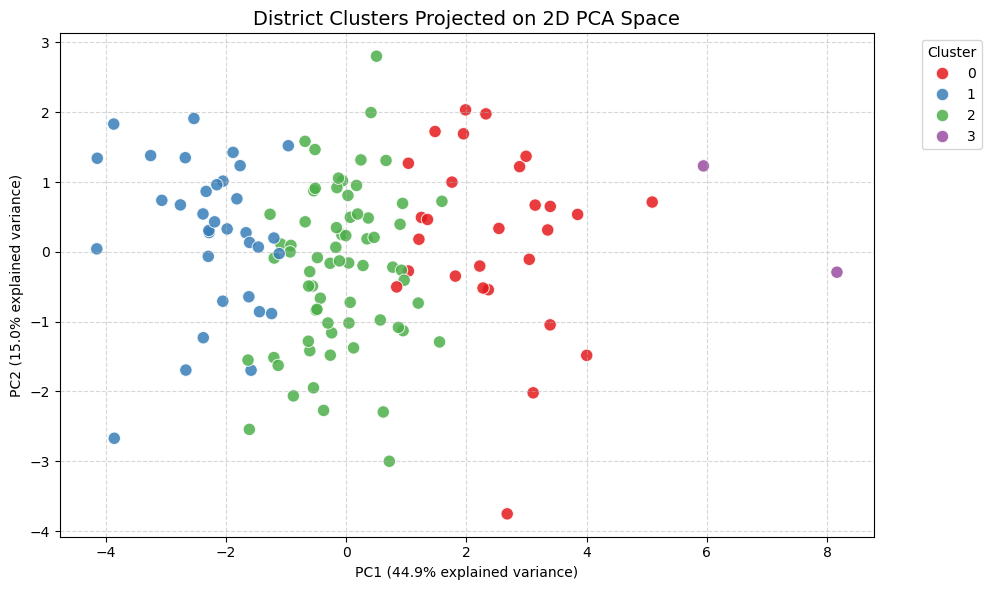

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Reduce the 9 scaled features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

d['pca_1'] = X_pca[:, 0]
d['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=d, 
    x='pca_1', 
    y='pca_2', 
    hue='cluster', 
    palette='Set1', 
    s=80, 
    alpha=0.85
)

plt.title('District Clusters Projected on 2D PCA Space', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} explained variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} explained variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

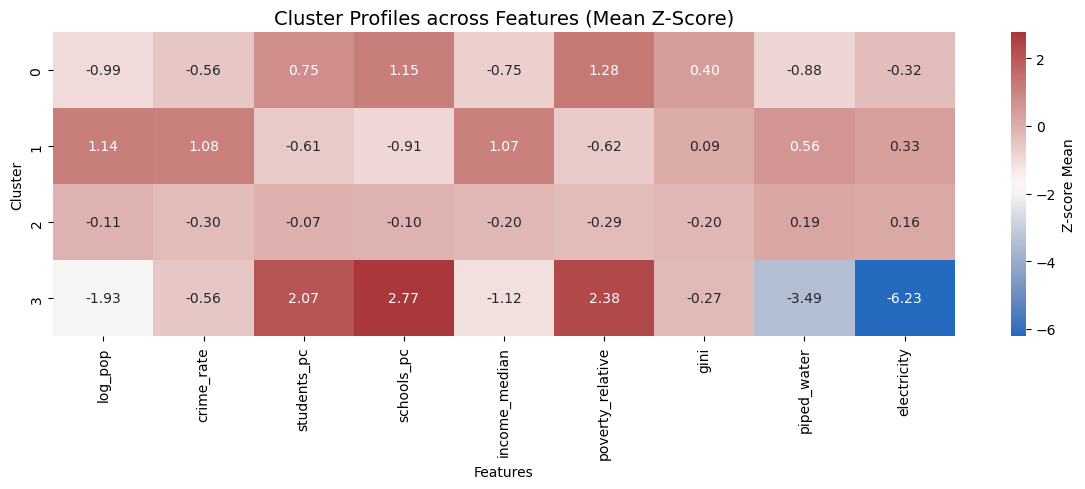

In [45]:
# Create a DataFrame of standardized feature values mapped to clusters
X_df = pd.DataFrame(X, columns=feats, index=d.index)
X_df['cluster'] = d['cluster']

# Compute the mean Z-score per feature per cluster
cluster_profiles = X_df.groupby('cluster').mean()

plt.figure(figsize=(12, 5))
sns.heatmap(
    cluster_profiles, 
    annot=True, 
    cmap='vlag', 
    fmt='.2f', 
    cbar_kws={'label': 'Z-score Mean'}
)
plt.title('Cluster Profiles across Features (Mean Z-Score)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

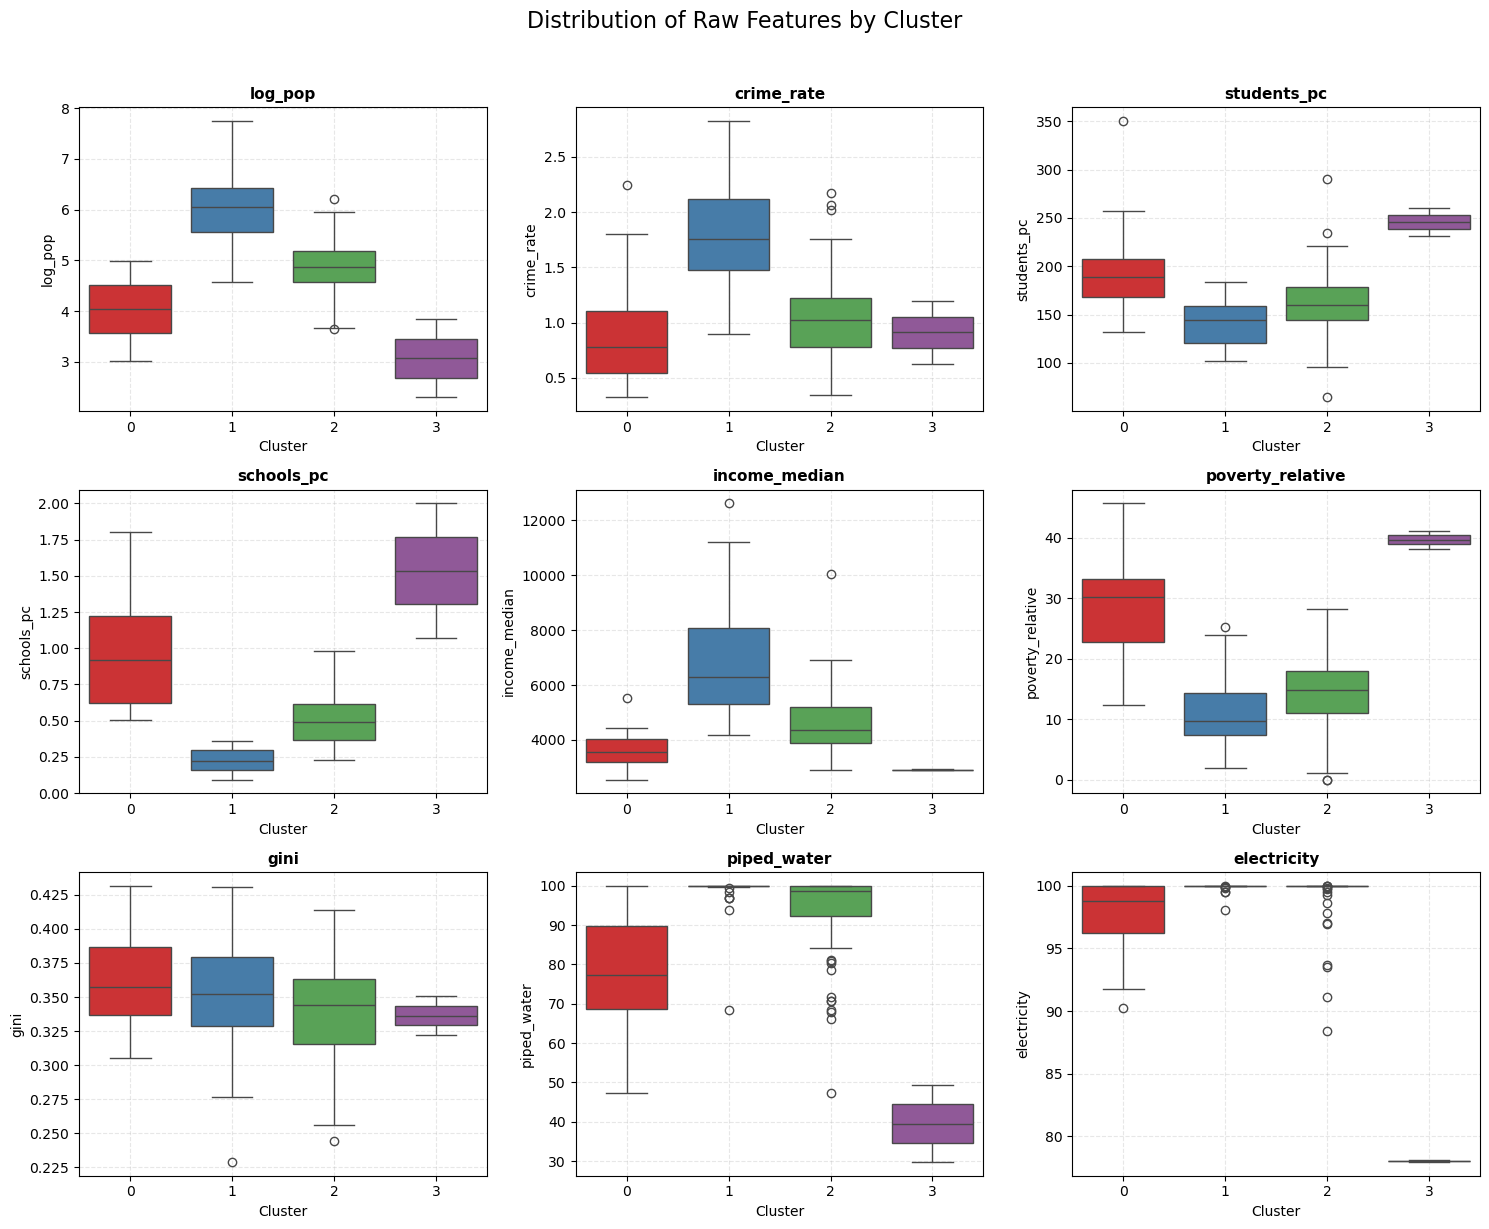

In [46]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feat in enumerate(feats):
    sns.boxplot(
        data=d, 
        x='cluster', 
        y=feat, 
        ax=axes[idx], 
        palette='Set1',
        hue='cluster',
        legend=False
    )
    axes[idx].set_title(feat, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Distribution of Raw Features by Cluster', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()